In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/breast-cancer.csv')

In [3]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'].astype(str))

print (df.head(20))
# 1 = M
# 0 = B

          id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0     842302          1        17.99         10.38          122.80     1001.0   
1     842517          1        20.57         17.77          132.90     1326.0   
2   84300903          1        19.69         21.25          130.00     1203.0   
3   84348301          1        11.42         20.38           77.58      386.1   
4   84358402          1        20.29         14.34          135.10     1297.0   
5     843786          1        12.45         15.70           82.57      477.1   
6     844359          1        18.25         19.98          119.60     1040.0   
7   84458202          1        13.71         20.83           90.20      577.9   
8     844981          1        13.00         21.82           87.50      519.8   
9   84501001          1        12.46         24.04           83.97      475.9   
10    845636          1        16.02         23.24          102.70      797.8   
11  84610002          1     

In [4]:
df.tail(
    
)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [5]:
df = df.drop('id',axis=1)

In [6]:
# Remove outliers using the IQR method for all numeric columns
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
print('Shape after outlier removal:', df_clean.shape)
df = df_clean.reset_index(drop=True)


Shape after outlier removal: (277, 31)


In [7]:
x = df.drop(['diagnosis'], axis =1)
y = df['diagnosis']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0         14.680         20.13           94.74      684.5          0.09867   
1         13.540         14.36           87.46      566.3          0.09779   
2         13.080         15.71           85.63      520.0          0.10750   
3          9.504         12.44           60.34      273.9          0.10240   
4         13.030         18.42           82.61      523.8          0.08983   
..           ...           ...             ...        ...              ...   
272       12.770         29.43           81.35      507.9          0.08276   
273       12.880         28.92           82.50      514.3          0.08123   
274       10.290         27.61           65.67      321.4          0.09030   
275       14.050         27.15           91.38      600.4          0.09929   
276       16.600         28.08          108.30      858.1          0.08455   

     compactness_mean  concavity_mean  concave points_mean  sym

In [8]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth= 4, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=10))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}


In [9]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [10]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.9910
DecisionTree testing accuracy: 0.8750
------------------------------
KNN training accuracy: 0.9412
KNN testing accuracy: 0.9643
------------------------------
Naive-Bayes training accuracy: 0.8869
Naive-Bayes testing accuracy: 0.8571
------------------------------


Classification Report for DecisionTree:
              precision    recall  f1-score   support

           0     0.9600    0.9057    0.9320        53
           1     0.1667    0.3333    0.2222         3

    accuracy                         0.8750        56
   macro avg     0.5633    0.6195    0.5771        56
weighted avg     0.9175    0.8750    0.8940        56

----------------------------------------


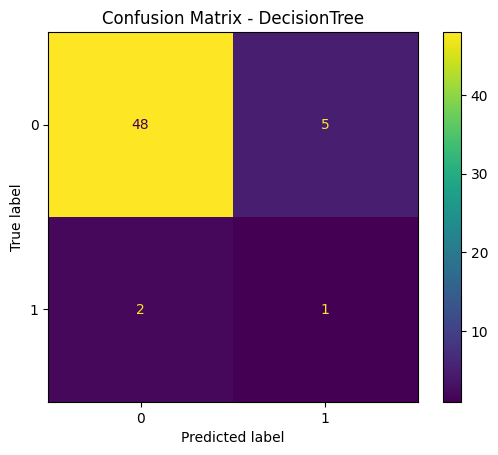

Classification Report for KNN:
              precision    recall  f1-score   support

           0     0.9636    1.0000    0.9815        53
           1     1.0000    0.3333    0.5000         3

    accuracy                         0.9643        56
   macro avg     0.9818    0.6667    0.7407        56
weighted avg     0.9656    0.9643    0.9557        56

----------------------------------------


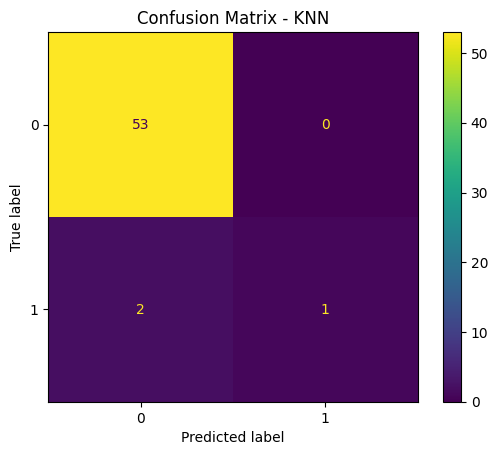

Classification Report for Naive-Bayes:
              precision    recall  f1-score   support

           0     1.0000    0.8491    0.9184        53
           1     0.2727    1.0000    0.4286         3

    accuracy                         0.8571        56
   macro avg     0.6364    0.9245    0.6735        56
weighted avg     0.9610    0.8571    0.8921        56

----------------------------------------


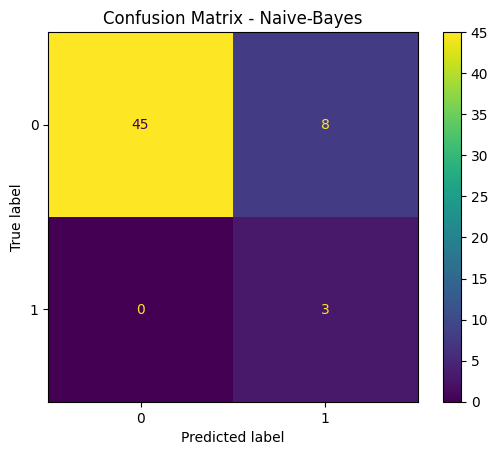

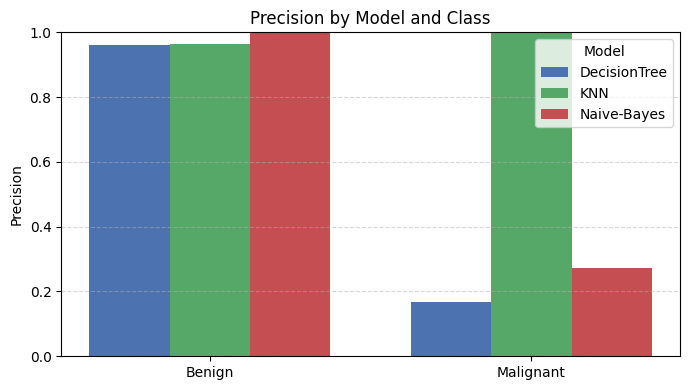

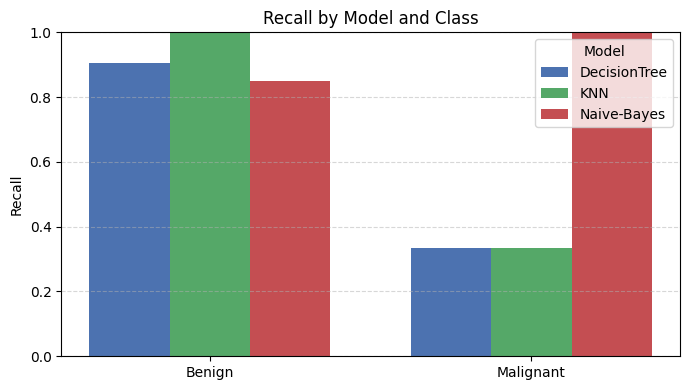

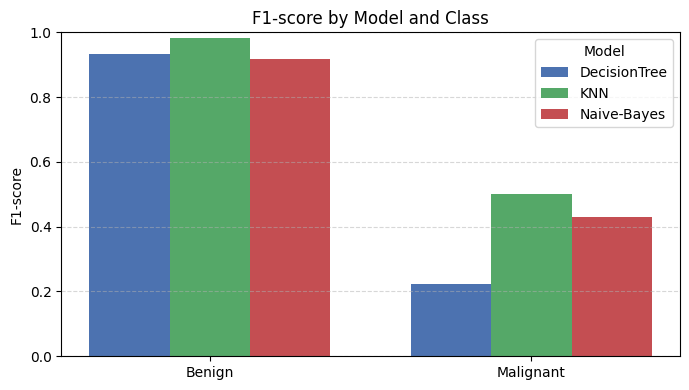

Support (number of samples per class in test set):
           DecisionTree  KNN  Naive-Bayes
Benign               53   53           53
Malignant             3    3            3


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Evaluate all models and store reports
model_reports = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred, digits=4))
    print("-" * 40)
    model_reports[name] = classification_report(y_test, y_pred, output_dict=True)
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# Individual metric bar graphs for all models
classes = ['0', '1']
class_names = ['Benign', 'Malignant']
metrics = ['precision', 'recall', 'f1-score']
colors = ['#4C72B0', '#55A868', '#C44E52']

for metric in metrics:
    plt.figure(figsize=(7, 4))
    for idx, (model_name, report) in enumerate(model_reports.items()):
        values = [report[cls][metric] for cls in classes]
        plt.bar(np.arange(len(classes)) + 0.25 * idx, values, width=0.25, label=model_name, color=colors[idx])
    plt.xticks(np.arange(len(classes)) + 0.25, class_names)
    plt.ylim(0, 1)
    plt.ylabel(metric.capitalize())
    plt.title(f'{metric.capitalize()} by Model and Class')
    plt.legend(title='Model')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Show support as a table for clarity
support_data = {model: [int(model_reports[model][cls]['support']) for cls in classes] for model in model_reports}
support_df = pd.DataFrame(support_data, index=class_names)
print('Support (number of samples per class in test set):')
print(support_df)


In [12]:
#cancer detection with lasso selected features (extracted in original file)
#radius_worst', 'area_worst', 'compactness_mean', 'radius_se', 'concavity_mean', 'concavity_se', 'concave points_mean', 'area_se', 'concavity_worst', 'fractal_dimension_worst

In [13]:
x = df[['radius_worst','area_worst', 'compactness_mean', 'radius_se', 'concavity_mean', 'concavity_se', 'concave points_mean', 'area_se', 'concavity_worst', 'fractal_dimension_worst']]
y = df['diagnosis' ]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)

     radius_worst  area_worst  compactness_mean  radius_se  concavity_mean  \
0           19.07      1138.0           0.07200     0.4727         0.07395   
1           15.11       711.2           0.08129     0.2699         0.06664   
2           14.50       630.5           0.12700     0.1852         0.04568   
3           10.23       314.9           0.06492     0.2773         0.02956   
4           13.30       545.9           0.03766     0.1839         0.02562   
..            ...         ...               ...        ...             ...   
272         13.87       594.7           0.04234     0.2409         0.01997   
273         13.89       595.7           0.05824     0.2116         0.06195   
274         10.84       357.6           0.07658     0.2199         0.05999   
275         15.30       706.7           0.11260     0.3645         0.04462   
276         18.98      1124.0           0.10230     0.4564         0.09251   

     concavity_se  concave points_mean  area_se  concavity_wors

In [14]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth= 4, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=10))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [16]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.9864
DecisionTree testing accuracy: 0.8929
------------------------------
KNN training accuracy: 0.9367
KNN testing accuracy: 0.9643
------------------------------
Naive-Bayes training accuracy: 0.9050
Naive-Bayes testing accuracy: 0.8036
------------------------------


In [17]:
#detection with RANDOMFOREST features (extracted in original file)

x = df[['area_worst', 'concave points_worst', 'concave points_mean', 'radius_worst', 'perimeter_worst', 'perimeter_mean', 'concavity_mean', 'area_mean', 'concavity_worst', 'radius_mean']]
y = df['diagnosis']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)


     area_worst  concave points_worst  concave points_mean  radius_worst  \
0        1138.0               0.16090              0.05259         19.07   
1         711.2               0.12880              0.04781         15.11   
2         630.5               0.07283              0.03110         14.50   
3         314.9               0.06227              0.02076         10.23   
4         545.9               0.05013              0.02923         13.30   
..          ...                   ...                  ...           ...   
272       594.7               0.06498              0.01499         13.87   
273       595.7               0.06493              0.02343         13.89   
274       357.6               0.09127              0.02738         10.84   
275       706.7               0.10480              0.04304         15.30   
276      1124.0               0.14180              0.05302         18.98   

     perimeter_worst  perimeter_mean  concavity_mean  area_mean  \
0             123.40

In [18]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth= 4, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=10))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [20]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.9910
DecisionTree testing accuracy: 0.8393
------------------------------
KNN training accuracy: 0.9457
KNN testing accuracy: 0.8750
------------------------------
Naive-Bayes training accuracy: 0.8914
Naive-Bayes testing accuracy: 0.7857
------------------------------
